## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

Vision Transformer 특징
- 셀프 어텐션으로 이미지 전체를 한번에 처리
- 이미지를 패치 단위로 나눠서 순차적으로 입력
- 작은 모델로도 높은 성능 낼 수 있음
- 입력 이미지 크기가 고정되어 있어서 크기가 다르면 전처리 필요
- 패치 간 상대적 위치 정보만 고려 -> 이미지 변형에 취약

CNN vs ViT
- CNN은 합성곱 계층으로 local feature 추출
- ViT는 셀프 어텐션으로 전체 이미지 관계 학습


- CNN: 이미지 일부 영역만 학습 (고양이 눈)
- ViT: 모든 패치가 서로 영향을 주며 학습


- CNN: 좁은 수용 영역 -> 깊은 계층이 필요함
- ViT: 레이어 하나로 전체 이미지 정보 표현 가능

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
# !curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
# !python pytorch-xla-env-setup.py --version 1.7
!pip install timm
# !pip install torch_xla

### 데이터 불러오기

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip -o /content/drive/MyDrive/mydata/train_images -d /content/drive/MyDrive/mydata/train_images

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/drive/MyDrive/mydata/train_images/3952546193.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3952799769.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953140534.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953222407.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953247024.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953327881.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953331047.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953514366.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953530273.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953560426.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953648207.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953857113.jpg  
  inflating: /content/drive/MyDrive/mydata/train_images/3953901317.jpg  
  inflating: /c

In [21]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip -o /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/mydata/

Archive:  /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth.zip
  inflating: /content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth  


In [22]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/mydata/"
TRAIN_PATH = "/content/drive/MyDrive/mydata/train_images"
TEST_PATH = "/content/drive/MyDrive/mydata/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/mydata/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

# import torch_xla
# import torch_xla.core.xla_model as xm
# import torch_xla.distributed.xla_multiprocessing as xmp
# import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

In [8]:
# os.environ["XLA_USE_BF16"] = "1"
# os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [24]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [25]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
# GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [26]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

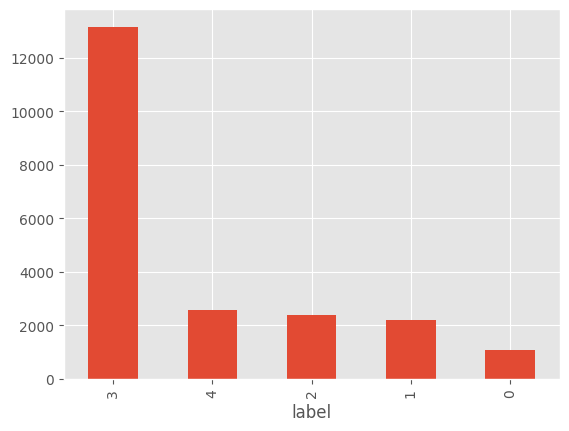

In [28]:
df.label.value_counts().plot(kind="bar")

In [29]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=42, stratify=df.label.values
)

In [30]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [31]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [32]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [33]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__() # nn.Module의 초기화 메서드 호출

        self.model = timm.create_model("vit_base_patch16_224", pretrained=False) # timm 라이브러리로 사전 정의된 ViT 모델 생성
        if pretrained: # pretraine = True -> 사전 학습된 파라미터 불러와서 모델에 로드
            self.model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))  # GPU 환경에서도 호환되게 로드

        self.model.head = nn.Linear(self.model.head.in_features, n_classes) # ViT의 linear layer를 현재 데이터셋 클래스 수에 맞게 바꿈

    def forward(self, x): # 순전파 정의: 입력 x를 모델에 통과시켜서 결과 반환
        x = self.model(x)
        return x

    # 한 epoch 동안의 학습 수행 함수
    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        epoch_loss = 0.0 # 에포크 전체 손실 초기화
        epoch_accuracy = 0.0 # 에포크 전체 정확도 초기화

        self.model.train() # 모델을 학습 모드로 전환
        for i, (data, target) in enumerate(train_loader): # GPU/TPU 사용시 맞춰서 메모리 이동
            if device.type == "cuda":  # GPU 사용 시
                data, target = data.cuda(), target.cuda()

            optimizer.zero_grad() # 이전 배치의 gradient 초기화
            output = self.forward(data) # 순전파 수행
            loss = criterion(output, target) # 손실 계산
            loss.backward() # 손실 기준으로 역전파 수행
            accuracy = (output.argmax(dim=1) == target).float().mean() # 예측 결과 중 최대 확률 클래스 vs 실제 정답 정확도 계산

            # 에포크 누적 손실/정확도 갱신
            epoch_loss += loss
            epoch_accuracy += accuracy

            optimizer.step() # 옵티마이저 업데이트 (GPU에서는 xm.optimizer_step 불필요)

            if i % 20 == 0: # 20번째 배치마다 학습 상태 출력
                print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss.item():.4f}")

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader) # 평균 손실 & 평균 정확도 반환

    # 검증 단계 수행 함수
    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0 # 검증 손실 초기화
        valid_accuracy = 0.0 # 검증 정확도 초기화

        self.model.eval() # 모델을 평가 모드로 전환 (dropout, batchnorm 비활성화)
        for data, target in valid_loader:
            if device.type == "cuda":  # GPU 사용 시
                data, target = data.cuda(), target.cuda()

            # 검증은 gradient 계산 생략
            with torch.no_grad():
                output = self.model(data) # 순전파만 수행
                loss = criterion(output, target) # 손실 계산
                accuracy = (output.argmax(dim=1) == target).float().mean() # 정확도 계산

                # 손실/정확도 누적 계산
                valid_loss += loss
                valid_accuracy += accuracy

        # 전체 검증 세트에 대한 평균 손실 & 정확도 반환
        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)


In [34]:
def fit_gpu(model, epochs, device, criterion, optimizer, train_loader, valid_loader=None):
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []

    for epoch in range(1, epochs + 1):
        gc.collect()
        print("="*50)
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(train_loader, criterion, optimizer, device)
        print(f"[TRAIN] EPOCH {epoch} - LOSS: {train_loss:.4f}, ACCURACY: {train_acc:.4f}")

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        if valid_loader is not None:
            gc.collect()
            print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(valid_loader, criterion, device)
            print(f"[VALID] LOSS: {valid_loss:.4f}, ACCURACY: {valid_acc:.4f}")

            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }


In [20]:
# model = ViTBase16(n_classes=5, pretrained=True)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = CassavaDataset(train_df, transforms=transforms_train)
valid_dataset = CassavaDataset(valid_df, transforms=transforms_valid)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
valid_loader = torch.utils.data.DataLoader(
    dataset=valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

model = ViTBase16(n_classes=5, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

start_time = datetime.now()
print(f"Start Time: {start_time}")

logs = fit_gpu(model, N_EPOCHS, device, criterion, optimizer, train_loader, valid_loader)

print(f"Execution time: {datetime.now() - start_time}")

# 모델 저장
torch.save(model.state_dict(), f'model_gpu_{datetime.now().strftime("%Y%m%d-%H%M")}.pth')
print("Model saved successfully!")


Start Time: 2025-11-10 15:41:34.115767
EPOCH 1 - TRAINING...
	BATCH 1/1204 - LOSS: 1.6444
	BATCH 21/1204 - LOSS: 1.4797
	BATCH 41/1204 - LOSS: 0.7291
	BATCH 61/1204 - LOSS: 0.4256
	BATCH 81/1204 - LOSS: 0.6577
	BATCH 101/1204 - LOSS: 0.7000
	BATCH 121/1204 - LOSS: 0.3454
	BATCH 141/1204 - LOSS: 0.6901
	BATCH 161/1204 - LOSS: 0.8180
	BATCH 181/1204 - LOSS: 0.5937
	BATCH 201/1204 - LOSS: 0.9152
	BATCH 221/1204 - LOSS: 0.5613
	BATCH 241/1204 - LOSS: 0.5942
	BATCH 261/1204 - LOSS: 0.6739
	BATCH 281/1204 - LOSS: 0.4674
	BATCH 301/1204 - LOSS: 0.3860
	BATCH 321/1204 - LOSS: 0.3472
	BATCH 341/1204 - LOSS: 0.3265
	BATCH 361/1204 - LOSS: 0.3164
	BATCH 381/1204 - LOSS: 0.6062
	BATCH 401/1204 - LOSS: 0.3841
	BATCH 421/1204 - LOSS: 0.4792
	BATCH 441/1204 - LOSS: 0.3864
	BATCH 461/1204 - LOSS: 0.8428
	BATCH 481/1204 - LOSS: 0.7346
	BATCH 501/1204 - LOSS: 0.3372
	BATCH 521/1204 - LOSS: 0.6942
	BATCH 541/1204 - LOSS: 0.5345
	BATCH 561/1204 - LOSS: 0.6101
	BATCH 581/1204 - LOSS: 0.3163
	BATCH 601/1204